<font size="+3"><strong>4.2. Predicting Damage with Logistic Regression</strong></font>

In [1]:
# ---------------------------------------------------------------
# 📊 Importing Essential Libraries
# ---------------------------------------------------------------

# Ignore warnings of type 'FutureWarning' to prevent clutter in the output
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# Used to create visual plots and charts
import matplotlib.pyplot as plt   

# Provides support for large, multi-dimensional arrays and math operations
import numpy as np  

# Used for data manipulation and analysis using DataFrames
import pandas as pd  

# Builds on matplotlib for easier statistical plotting
import seaborn as sns  

# Import encoder to convert categorical variables into numeric format
from category_encoders import OneHotEncoder

# Import logistic regression model for binary/multi-class classification
from sklearn.linear_model import LogisticRegression

# Import metric function to measure model accuracy
from sklearn.metrics import accuracy_score

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import pipeline tools to chain preprocessing and modeling steps together
from sklearn.pipeline import Pipeline, make_pipeline


# Prepare Data

## Import data

In [2]:
def wrangle(filepath):
    df=pd.read_csv(filepath) 

    df['damage_grade'] = df['damage_grade'].fillna(df['damage_grade'].mode()[0])
    # Identify leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]
    
    # Create binary target
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int) 
    
    # Drop old target
    drop_cols.append("damage_grade")

    # Drop multicolinearity column
    drop_cols.append("count_floors_pre_eq")

    # Drop high categorical features
    drop_cols.append("building_id")

    # Drop columns
    df.drop(columns=drop_cols, inplace=True)

    return df


In [3]:
df = wrangle("../NepalEarhquakeDamage2015.csv")
df.head()

,district_id,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
0,12,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
1,12,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
2,12,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
3,12,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
4,12,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0


## 🏚️ Creating a Binary Target and Dropping Post-Earthquake Features

In this step, we prepare our data for building a **binary classification model**.  
Currently, the target variable `"damage_grade"` has multiple categories representing the severity of damage to each building.

To simplify this into a binary problem, we'll create a new target column called **`"severe_damage"`**, where:
- Buildings with `"damage_grade"` **4 or above** will be labeled as **1 (Severe Damage)**
- Buildings with `"damage_grade"` **below 4** will be labeled as **0 (Not Severe)**

We’ll also remove the original `"damage_grade"` column to avoid data leakage.

Additionally, some features contain information collected **after** the earthquake — these are identified by the substring `"post_eq"`.  
Including them could leak future information into our model, so we'll drop all such columns within the `wrangle()` function.

### To implement this:
1. Update the `wrangle()` function to:
   - Drop all columns containing `"post_eq"`.
   - Create a new binary column `"severe_damage"`.
   - Drop the original `"damage_grade"` column.
2. Re-run all cells above to apply the updated data preparation steps.

This ensures our model is trained only on **pre-earthquake information** and learns to **classify buildings as severely or non-severely damaged**.


## Explore data

## 📊 Checking for Multicollinearity with a Correlation Heatmap

Before training a **linear model**, it’s important to check for **multicollinearity** —  
a condition where two or more features are highly correlated with each other.  
High correlations can cause instability in the model coefficients and reduce interpretability.

To detect this, we’ll create a **correlation heatmap** using the numerical features in our dataset.

### Steps:
1. Select only the **numerical features** from `df` (excluding the target column `"severe_damage"`).
2. Compute the **correlation matrix** between these features.
3. Visualize the results using a **seaborn heatmap** to identify highly correlated pairs.

This visualization helps us spot features that may provide redundant information and should potentially be removed or combined before modeling.


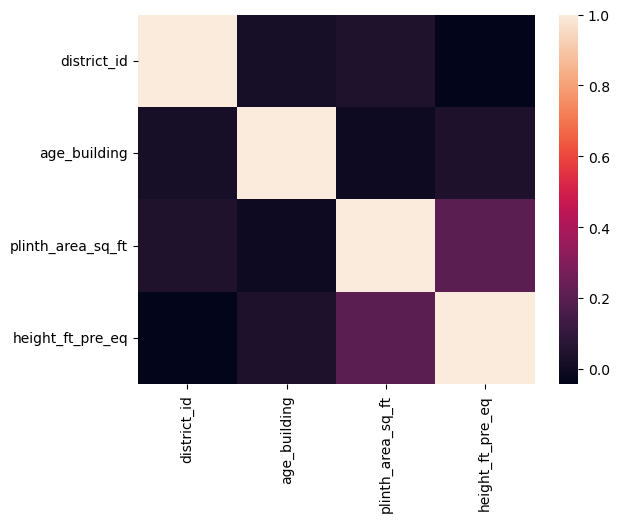

In [4]:
correlation = df.select_dtypes("number").drop(columns="severe_damage").corr()
sns.heatmap(correlation);

## 🏗️ Exploring Building Height and Damage Severity

Now that we’ve created our binary target `"severe_damage"`, let’s explore how building height relates to earthquake damage.

### 1️⃣ Boxplot — Building Height vs. Damage Severity
We’ll use a **Seaborn boxplot** to compare the distribution of `"height_ft_pre_eq"` (building height before the earthquake)  
for both groups in `"severe_damage"`:
- **0 → Not Severe Damage**  
- **1 → Severe Damage**

This visualization helps us understand whether taller buildings are more likely to experience severe damage.

### 2️⃣ Bar Chart — Distribution of Severe Damage Classes
Next, we’ll visualize the **proportion of buildings** that fall into each `"severe_damage"` category.  
Instead of raw counts, we’ll plot **relative frequencies** (percentages) by setting `normalize=True` in the `value_counts()` function.

This gives us a clearer sense of how balanced our target classes are — an important step before model training.


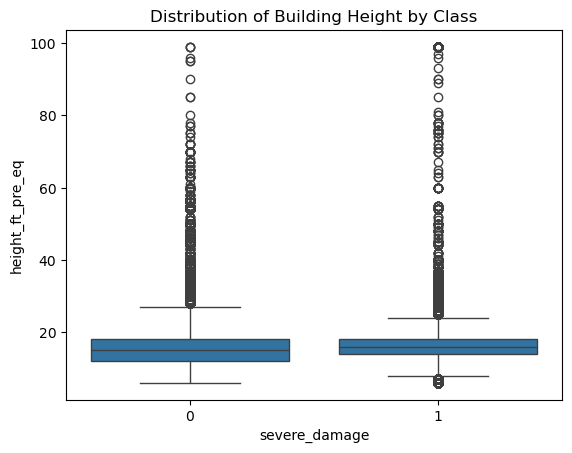

In [5]:
sns.boxplot(x="severe_damage", y="height_ft_pre_eq",data=df)
plt.xlabel("severe_damage")
plt.ylabel("height_ft_pre_eq")
plt.title("Distribution of Building Height by Class");

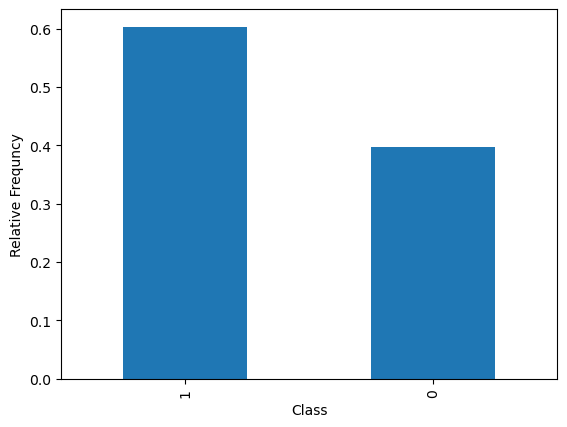

In [6]:
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", xlabel="Class", ylabel="Relative Frequncy"
);

## 🧱 Analyzing Damage Severity by Foundation Type

In this step, we’ll explore how **building foundation types** relate to the likelihood of severe earthquake damage.  
We’ll also check for class imbalance and examine categorical feature cardinality.

---

### 1️⃣ Checking Class Proportions
First, we’ll calculate the **normalized proportions** of each class in our target column `"severe_damage"`.  
We’ll store these values in two variables:
- `majority_class_prop` → Proportion of the majority class  
- `minority_class_prop` → Proportion of the minority class  

This helps us understand whether our dataset is balanced or skewed toward one damage category.

---

### 2️⃣ Pivot Table — Foundation Type vs. Severe Damage
Next, we’ll create a **pivot table** where:
- The index is `"foundation_type"`  
- The values come from `"severe_damage"`  
- The aggregation function is the **mean**

Since `"severe_damage"` is binary (0 or 1), the mean represents the **proportion of severely damaged buildings** within each foundation type.

---

### 3️⃣ Visualizing with a Horizontal Bar Chart
We’ll then visualize `foundation_pivot` as a **horizontal bar chart**,  
adding **vertical reference lines** for `majority_class_prop` and `minority_class_prop`.  
This allows us to compare how each foundation type’s severe-damage rate  
differs from the overall dataset proportions.

---

### 4️⃣ Checking Categorical Feature Cardinality
Finally, we’ll get rid of too high or too low carniality features and then update the wrangle function and re-run all the above cells.


In [7]:
majority_class_prop, minority_class_prop = df["severe_damage"].value_counts(normalize=True)
print(majority_class_prop, minority_class_prop)

0.6030945826433594 0.3969054173566407


In [8]:
foundation_pivot = pd.pivot_table(
    df, index="foundation_type",values="severe_damage", aggfunc=np.mean
).sort_values(by="severe_damage")
foundation_pivot

,severe_damage
foundation_type,
RC,0.038263
Bamboo/Timber,0.237868
Cement-Stone/Brick,0.296904
Other,0.510545
Mud mortar-Stone/Brick,0.685120


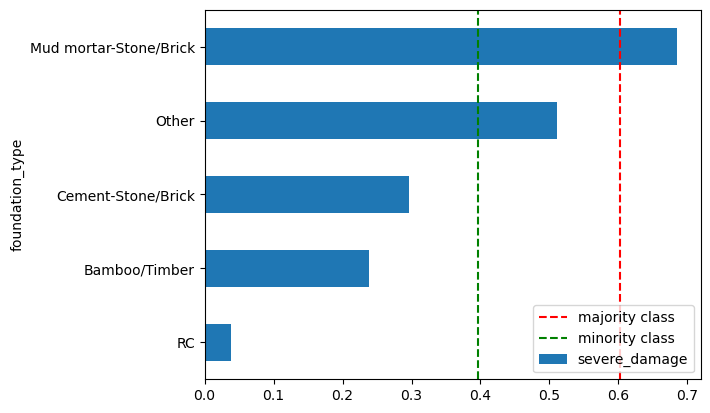

In [9]:
foundation_pivot.plot(kind="barh")
plt.axvline(
    majority_class_prop, linestyle="--" , color ="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--" , color ="green", label="minority class"
)
plt.legend(loc="lower right");

## Split

## 🏗️ Preparing Features and Target for Modeling

Before training our model, we need to separate the data into **features** and **target**:

- **Feature matrix (`X`)**: Contains all predictor variables used to predict damage.  
- **Target vector (`y`)**: Contains the binary target `"severe_damage"`.

---

### Splitting the Data
To evaluate our model’s performance properly, we’ll split the dataset into:

- **Training set**: 80% of the data, used to train the model  
- **Test set**: 20% of the data, used to evaluate the model on unseen data  

We’ll use a **randomized train-test split** and set a `random_state` to ensure the split is **reproducible**.  

This step ensures our model is trained on one subset of data while being evaluated on completely unseen examples, giving a reliable estimate of performance.


In [10]:
target = "severe_damage"
X = df.drop(columns=target)
y = df[target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (609684, 11)
y_train shape: (609684,)
X_test shape: (152422, 11)
y_test shape: (152422,)


# Build Model

## Baseline

## 🎯 Calculating Baseline Accuracy

Before training any machine learning model, it’s important to establish a **baseline performance**.  

For a classification problem, the baseline accuracy is simply the proportion of the **majority class** in the target variable.  
This gives us a reference point — our model should **perform better than simply guessing the most frequent class**.

By calculating the baseline accuracy, we can:

- Understand how skewed our target classes are  
- Set a minimum performance threshold for the model  

Any model we build should aim to exceed this baseline to be considered useful.


In [12]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.6


## Iterate

## 🤖 Building a Logistic Regression Pipeline

Now that our data is prepared, we’ll create a **machine learning pipeline** to train a model.  

### Pipeline Components:
1. **OneHotEncoder**:  
   - Converts categorical features into numeric format so the model can process them.  
   - We set `use_cat_names=True` to keep the transformed feature names readable.

2. **LogisticRegression**:  
   - A simple, interpretable linear model suitable for **binary classification**.  
   - Predicts the probability that a building will suffer severe damage.

### Why a Pipeline?
- Ensures that preprocessing and modeling steps are applied **consistently** to both training and test data.  
- Makes the workflow cleaner and reproducible.

Finally, we **fit the pipeline to the training data**, allowing the model to learn the relationship between the features and `"severe_damage"`.


In [13]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['land_surface_condition',
                                     'foundation_type', 'roof_type',
                                     'ground_floor_type', 'other_floor_type',
                                     'position', 'plan_configuration'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

## Evaluate

## 📊 Evaluating Model Performance

After training our logistic regression pipeline, it’s important to assess how well it performs.

### Accuracy Scores:
- **Training Accuracy**: Measures how well the model fits the training data.  
  - High training accuracy shows the model has learned the patterns in the training set.  
- **Test Accuracy**: Measures how well the model generalizes to unseen data.  
  - Provides a realistic estimate of the model’s performance in real-world scenarios.

By comparing training and test accuracy, we can also check for **overfitting** or **underfitting**:
- **Overfitting**: High training accuracy, low test accuracy  
- **Underfitting**: Both training and test accuracy are low  

Calculating these scores gives us a clear view of how reliable our model is.


In [15]:
acc_train = accuracy_score(y_train,model.predict(X_train))
acc_test = model.score(X_test,y_test)

print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.72
Test Accuracy: 0.72


# Communicate

## 📈 Interpreting Model Predictions and Feature Importances

Once our logistic regression model is trained, we can dive deeper into understanding **how it makes predictions** and which features are most influential.

---

### 1️⃣ `predict_proba` vs `predict`
- Using `predict` gives the **final class labels** (0 or 1 for `"severe_damage"`).  
- Using `predict_proba` returns the **predicted probabilities** for each class.  
  - For example, a row might have `[0.7, 0.3]`, meaning the model predicts a 70% chance of class 0 and 30% chance of class 1.  
- Probabilities provide more nuanced information, useful for decision thresholds and risk assessment.

---

### 2️⃣ Feature Importances and Odds Ratios
- We can extract **feature names** and their corresponding **coefficients** from the logistic regression model.  
- By taking the **exponential of the coefficients**, we obtain **odds ratios**:
  - Odds ratio > 1 → Feature increases the odds of severe damage  
  - Odds ratio < 1 → Feature decreases the odds of severe damage  
- This representation is different from other linear models (like linear regression) because it directly expresses the **multiplicative effect** of features on the odds of the outcome.

---

### 3️⃣ Visualizing Important Features
We can create **horizontal bar charts** to highlight the most and least influential features:

1. **Top 5 Positive Odds Ratios**  
   - Shows features that most strongly **increase** the odds of severe damage  
   - Label the x-axis `"Odds Ratio"`

2. **Top 5 Negative Odds Ratios**  
   - Shows features that most strongly **decrease** the odds of severe damage  
   - Label the x-axis `"Odds Ratio"`

These charts make it easier to interpret the model and communicate which building characteristics are most associated with severe earthquake damage.


In [16]:
y_train_pred_proba = model.predict_proba(X_train)
print(y_train_pred_proba[:5])

[[0.3075326  0.6924674 ]
 [0.75308313 0.24691687]
 [0.31366417 0.68633583]
 [0.2446943  0.7553057 ]
 [0.41422483 0.58577517]]


In [18]:
features = model.named_steps["onehotencoder"].get_feature_names()
importances = model.named_steps["logisticregression"].coef_[0]

In [19]:
odds_ratios = pd.Series(np.exp(importances),index=features).sort_values()
odds_ratios.head()

ground_floor_type_RC             0.288649
foundation_type_Bamboo/Timber    0.349641
roof_type_RCC/RB/RBC             0.374128
foundation_type_RC               0.480370
plan_configuration_L-shape       0.543427
dtype: float64

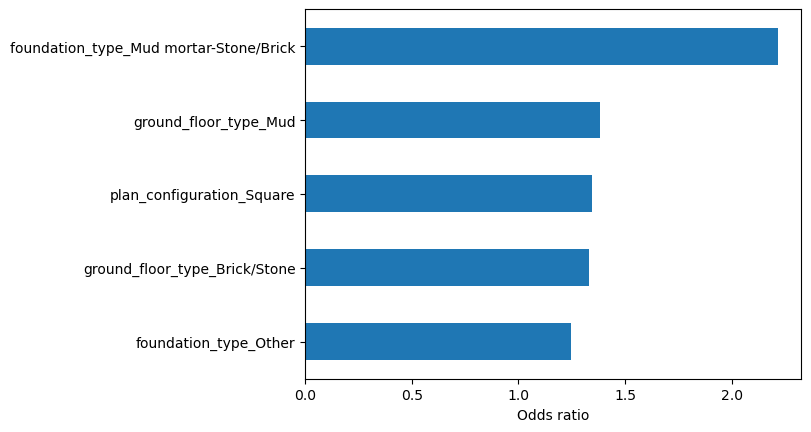

In [20]:
odds_ratios.tail().plot(kind="barh")
plt.xlabel("Odds ratio");

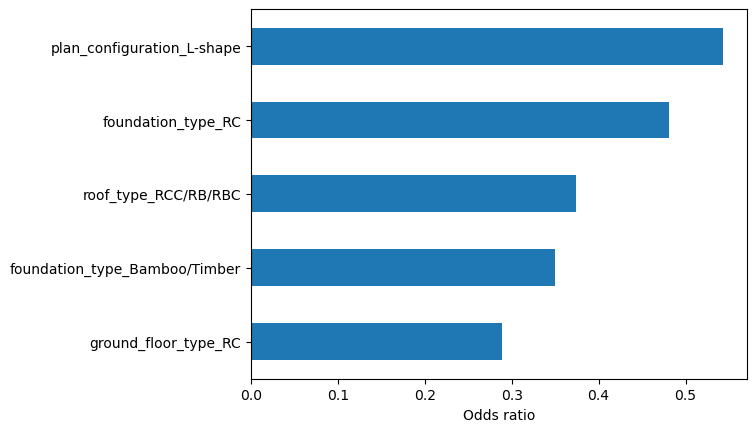

In [21]:
odds_ratios.head().plot(kind="barh")
plt.xlabel("Odds ratio");

## 🏁 Conclusion

In this project, we built a **binary classification model** to predict severe earthquake damage to buildings.  

### Key Takeaways:
- We carefully **cleaned and preprocessed** the data, removing post-earthquake features and handling missing values.  
- We created a **binary target (`severe_damage`)** to simplify the problem and focus on high-risk buildings.  
- **Exploratory analysis** revealed relationships between building characteristics, such as foundation type and height, and the likelihood of severe damage.  
- We trained a **logistic regression pipeline** with one-hot encoding for categorical features and evaluated its performance using training and test accuracy.  
- By examining **feature importances and odds ratios**, we identified which characteristics increase or decrease the risk of severe damage.  

This project demonstrates how machine learning can help prioritize earthquake recovery efforts by **predicting high-risk buildings**, while highlighting the importance of **data cleaning, feature engineering, and careful model interpretation**.
